In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 🎯 MILESTONE 3: COMPETITOR ANALYSIS & REVENUE OPTIMIZATION"))
display(Markdown("### 📥 Step 1: Load Your Products + Competitor Data"))

# Your own retail pricing data
own_products = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\retail_pricing_demand_clean.csv")

# Competitor data (Amazon UK Products)
competitor_products = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\amazon_uk_products_clean.csv")

print("Own Products Shape:", own_products.shape)
print("Own Products Categories:", own_products['category'].unique())

print("\nCompetitor Products Shape:", competitor_products.shape)
print("Competitor Categories (sample):", competitor_products['categoryName'].unique()[:15])

## 🎯 MILESTONE 3: COMPETITOR ANALYSIS & REVENUE OPTIMIZATION

### 📥 Step 1: Load Your Products + Competitor Data

Own Products Shape: (172800, 17)
Own Products Categories: <StringArray>
[      'Shoes',     'Apparel', 'Accessories', 'Electronics',      'Beauty',
   'Groceries',        'Home',      'Sports']
Length: 8, dtype: str

Competitor Products Shape: (2222724, 10)
Competitor Categories (sample): <StringArray>
[                  'Hi-Fi Speakers',          'CD, Disc & Tape Players',
              'Wearable Technology',                      'Light Bulbs',
                'Bathroom Lighting',   'Heating, Cooling & Air Quality',
       'Coffee & Espresso Machines',        'Lab & Scientific Products',
                   'Smart Speakers',               'Motorbike Clothing',
            'Motorbike Accessories',              'Motorbike Batteries',
        'Motorbike Boots & Luggage',                'Motorbike Chassis',
 'Handmade Home & Kitchen Products']
Length: 15, dtype: str


In [2]:
display(Markdown("### 🔗 Step 2: Category Mapping — Competitor to Own Categories"))

# See all unique competitor categories to identify matches
all_competitor_categories = competitor_products['categoryName'].unique()
print(f"Total competitor categories: {len(all_competitor_categories)}")

# Define keyword-based mapping for our 8 categories
category_keywords = {
    'Shoes': ['shoe', 'footwear', 'boot', 'sneaker', 'sandal'],
    'Apparel': ['clothing', 'apparel', 'shirt', 'dress', 'jacket', 'trouser'],
    'Accessories': ['accessor', 'jewelry', 'watch', 'bag', 'wallet'],
    'Electronics': ['electronic', 'speaker', 'headphone', 'camera', 'tv', 'laptop', 'phone'],
    'Beauty': ['beauty', 'makeup', 'skincare', 'cosmetic', 'fragrance'],
    'Groceries': ['grocery', 'food', 'snack', 'beverage', 'drink'],
    'Home': ['home', 'kitchen', 'furniture', 'decor', 'bedding'],
    'Sports': ['sport', 'fitness', 'gym', 'outdoor', 'athletic']
}

category_mapping = {}
for own_cat, keywords in category_keywords.items():
    matched = [c for c in all_competitor_categories if any(kw.lower() in c.lower() for kw in keywords)]
    category_mapping[own_cat] = matched
    print(f"\n{own_cat} → {len(matched)} matching competitor categories")
    print(f"  Examples: {matched[:5]}")

### 🔗 Step 2: Category Mapping — Competitor to Own Categories

Total competitor categories: 296

Shoes → 17 matching competitor categories
  Examples: ['Motorbike Boots & Luggage', 'Downhill Ski Boots', "Women's Sports & Outdoor Shoes", 'Tennis Shoes', 'Boating Footwear']

Apparel → 4 matching competitor categories
  Examples: ['Motorbike Clothing', 'Ski Clothing', 'Handmade Clothing, Shoes & Accessories', "Kids' Dress Up & Pretend Play"]

Accessories → 37 matching competitor categories
  Examples: ['Motorbike Accessories', 'Fireplaces, Stoves & Accessories', 'PC Gaming Accessories', 'Blank Media Cases & Wallets', 'General Music-Making Accessories']

Electronics → 23 matching competitor categories
  Examples: ['Hi-Fi Speakers', 'Smart Speakers', 'Microphones', 'Laptops', 'Mobile Phone Accessories']

Beauty → 3 matching competitor categories
  Examples: ['Fragrances', 'Beauty', 'Home Fragrance']

Groceries → 2 matching competitor categories
  Examples: ['Luxury Food & Drink', 'Grocery']

Home → 32 matching competitor categories
  Examples: ['Handma

In [3]:
display(Markdown("### 🔍 Step 3: Full Review of Category Mappings"))

for own_cat, matched_cats in category_mapping.items():
    print(f"\n{'='*50}")
    print(f"{own_cat} ({len(matched_cats)} matches)")
    print('='*50)
    for cat in matched_cats:
        count = (competitor_products['categoryName'] == cat).sum()
        print(f"  - {cat} ({count:,} products)")

### 🔍 Step 3: Full Review of Category Mappings


Shoes (17 matches)
  - Motorbike Boots & Luggage (250 products)
  - Downhill Ski Boots (1,279 products)
  - Women's Sports & Outdoor Shoes (1,958 products)
  - Tennis Shoes (4,669 products)
  - Boating Footwear (139 products)
  - Cycling Shoes (9,412 products)
  - Basketball Footwear (6,697 products)
  - Men's Sports & Outdoor Shoes (2,866 products)
  - Handmade Clothing, Shoes & Accessories (16,707 products)
  - Ballet & Dancing Footwear (2,982 products)
  - Cricket Shoes (287 products)
  - Golf Shoes (414 products)
  - Boxing Shoes (4,069 products)
  - Snowboard Boots (961 products)
  - Hockey Shoes (241 products)
  - Climbing Footwear (2,177 products)
  - Equestrian Sports Boots (399 products)

Apparel (4 matches)
  - Motorbike Clothing (484 products)
  - Ski Clothing (1,908 products)
  - Handmade Clothing, Shoes & Accessories (16,707 products)
  - Kids' Dress Up & Pretend Play (8,952 products)

Accessories (37 matches)
  - Motorbike Accessories (431 products)
  - Fireplaces, Stove

In [4]:
display(Markdown("### 🧹 Step 4: Cleaned Category Mapping (Manually Curated)"))

category_mapping_clean = {
    'Shoes': ['Tennis Shoes', 'Cycling Shoes', 'Basketball Footwear', "Women's Sports & Outdoor Shoes",
              "Men's Sports & Outdoor Shoes", 'Golf Shoes', 'Boxing Shoes', 'Climbing Footwear',
              'Snowboard Boots', 'Downhill Ski Boots'],
    'Apparel': ['Motorbike Clothing', 'Ski Clothing'],
    'Accessories': ['Smartwatches', 'Headphones, Earphones & Accessories', 'Camera & Photo Accessories',
                     'GPS, Finders & Accessories'],
    'Electronics': ['Hi-Fi Speakers', 'Smart Speakers', 'Microphones', 'Laptops', 'Mobile Phones & Smartphones',
                     'Digital Cameras', 'Action Cameras', 'Surveillance Cameras', 'Home Cinema, TV & Video'],
    'Beauty': ['Fragrances', 'Beauty', 'Home Fragrance'],
    'Groceries': ['Luxury Food & Drink', 'Grocery'],
    'Home': ['Furniture & Lighting', 'Living Room Furniture', 'Bedding & Linen', 'Small Kitchen Appliances',
             'Bedroom Furniture', 'Bathroom Furniture', 'Kitchen Storage & Organisation'],
    'Sports': ['Sports Toys & Outdoor', 'Sports Supplements', 'Equestrian Sports Boots',
               "Women's Sports & Outdoor Shoes", "Men's Sports & Outdoor Shoes"]
}

for own_cat, matched_cats in category_mapping_clean.items():
    total_products = competitor_products[competitor_products['categoryName'].isin(matched_cats)].shape[0]
    print(f"{own_cat}: {len(matched_cats)} categories, {total_products:,} competitor products")

### 🧹 Step 4: Cleaned Category Mapping (Manually Curated)

Shoes: 10 categories, 34,502 competitor products
Apparel: 2 categories, 2,392 competitor products
Accessories: 4 categories, 27,537 competitor products
Electronics: 9 categories, 48,587 competitor products
Beauty: 3 categories, 24,696 competitor products
Groceries: 2 categories, 6,953 competitor products
Home: 7 categories, 34,509 competitor products
Sports: 5 categories, 23,585 competitor products


In [5]:
display(Markdown("### 💰 Step 5: Price Comparison — Own vs Competitor"))

comparison_results = []

for own_cat, matched_cats in category_mapping_clean.items():
    own_avg_price = own_products[own_products['category'] == own_cat]['current_price'].mean()

    competitor_subset = competitor_products[competitor_products['categoryName'].isin(matched_cats)]
    competitor_avg_price = competitor_subset['price'].mean()
    competitor_median_price = competitor_subset['price'].median()

    price_gap = own_avg_price - competitor_avg_price
    price_gap_pct = (price_gap / competitor_avg_price) * 100

    comparison_results.append({
        'category': own_cat,
        'own_avg_price': round(own_avg_price, 2),
        'competitor_avg_price': round(competitor_avg_price, 2),
        'competitor_median_price': round(competitor_median_price, 2),
        'price_gap': round(price_gap, 2),
        'price_gap_pct': round(price_gap_pct, 1),
        'position': 'Above Market' if price_gap > 0 else 'Below Market'
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

### 💰 Step 5: Price Comparison — Own vs Competitor

   category  own_avg_price  competitor_avg_price  competitor_median_price  price_gap  price_gap_pct     position
      Shoes         193.56                 85.52                    60.94     108.05          126.3 Above Market
    Apparel         211.76                 62.31                    37.52     149.45          239.8 Above Market
Accessories         196.74                 59.39                    19.95     137.35          231.3 Above Market
Electronics         199.48                281.46                    55.09     -81.98          -29.1 Below Market
     Beauty         196.14                 31.15                    18.00     164.99          529.7 Above Market
  Groceries         189.43                 13.05                     9.99     176.38         1351.8 Above Market
       Home         214.64                 76.51                    34.99     138.13          180.6 Above Market
     Sports         180.88                 44.49                    22.25     136.39          30

### 🔍 Step 6: Verify Price Distributions (Sanity Check)

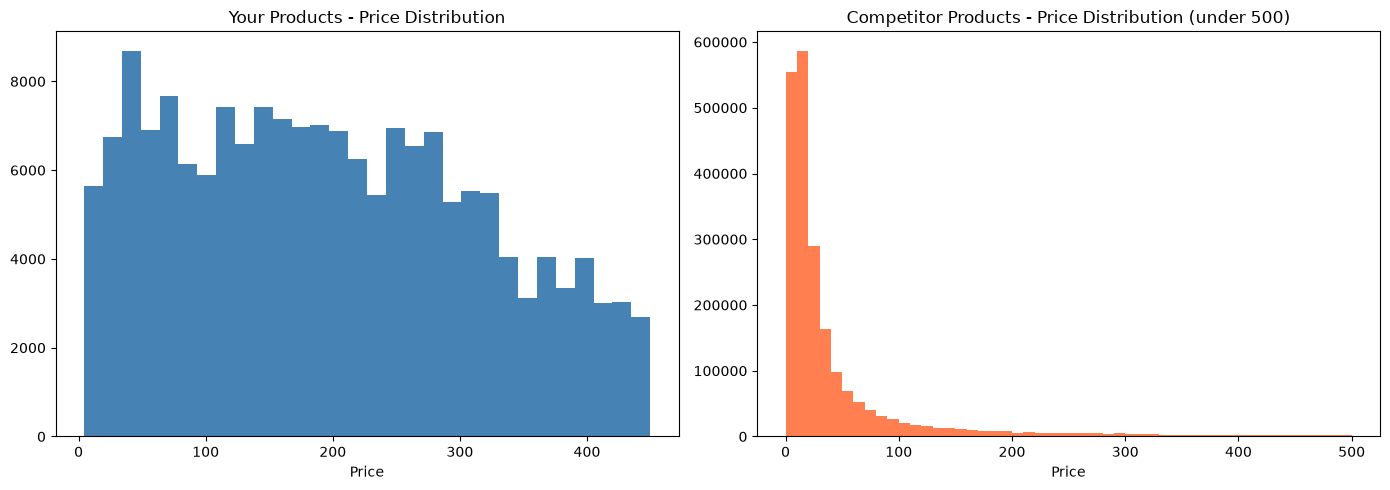

Your products - Min/Max/Mean: 4.28 / 449.74 / 197.82835966435184
Competitor - Min/Max/Mean: 0.01 / 100000.0 / 94.25813789296376


In [6]:
display(Markdown("### 🔍 Step 6: Verify Price Distributions (Sanity Check)"))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(own_products['current_price'], bins=30, color='steelblue')
axes[0].set_title('Your Products - Price Distribution')
axes[0].set_xlabel('Price')

axes[1].hist(competitor_products['price'], bins=50, range=(0,500), color='coral')
axes[1].set_title('Competitor Products - Price Distribution (under 500)')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

print("Your products - Min/Max/Mean:", own_products['current_price'].min(), "/", own_products['current_price'].max(), "/", own_products['current_price'].mean())
print("Competitor - Min/Max/Mean:", competitor_products['price'].min(), "/", competitor_products['price'].max(), "/", competitor_products['price'].mean())

In [7]:
display(Markdown("### 🔧 Step 7: Corrected Comparison Using Median (Robust to Outliers)"))

comparison_results_v2 = []

for own_cat, matched_cats in category_mapping_clean.items():
    own_avg_price = own_products[own_products['category'] == own_cat]['current_price'].mean()

    competitor_subset = competitor_products[competitor_products['categoryName'].isin(matched_cats)]
    competitor_median_price = competitor_subset['price'].median()

    price_gap = own_avg_price - competitor_median_price
    price_gap_pct = (price_gap / competitor_median_price) * 100

    comparison_results_v2.append({
        'category': own_cat,
        'own_avg_price': round(own_avg_price, 2),
        'competitor_median_price': round(competitor_median_price, 2),
        'price_gap': round(price_gap, 2),
        'price_gap_pct': round(price_gap_pct, 1),
        'position': 'Above Market' if price_gap > 0 else 'Below Market'
    })

comparison_df_v2 = pd.DataFrame(comparison_results_v2)
print(comparison_df_v2.to_string(index=False))

### 🔧 Step 7: Corrected Comparison Using Median (Robust to Outliers)

   category  own_avg_price  competitor_median_price  price_gap  price_gap_pct     position
      Shoes         193.56                    60.94     132.62          217.6 Above Market
    Apparel         211.76                    37.52     174.24          464.4 Above Market
Accessories         196.74                    19.95     176.79          886.2 Above Market
Electronics         199.48                    55.09     144.39          262.1 Above Market
     Beauty         196.14                    18.00     178.14          989.7 Above Market
  Groceries         189.43                     9.99     179.44         1796.2 Above Market
       Home         214.64                    34.99     179.65          513.4 Above Market
     Sports         180.88                    22.25     158.63          712.9 Above Market


### 📊 Step 8: Visualize Price Positioning

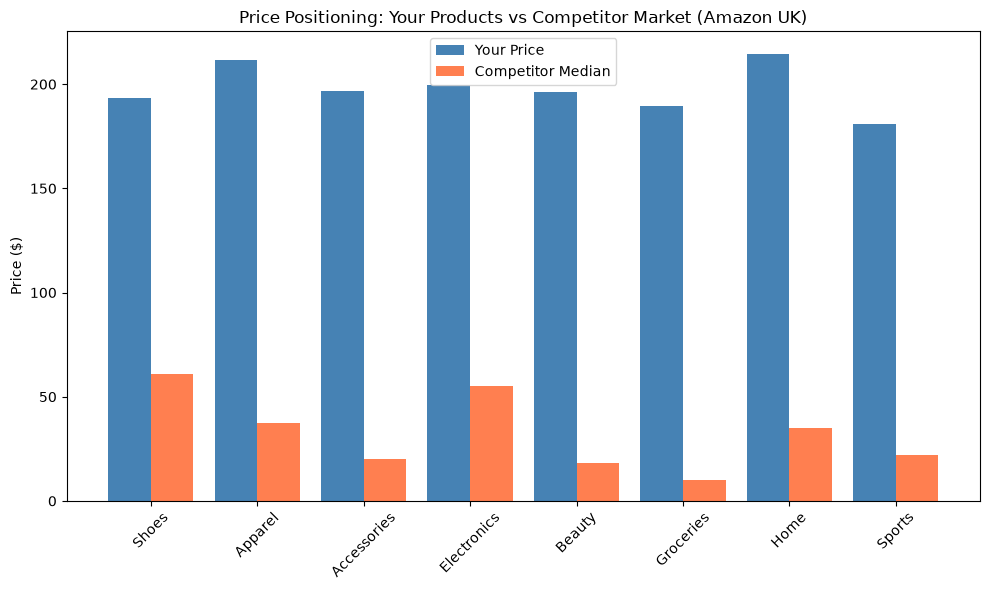

In [8]:
display(Markdown("### 📊 Step 8: Visualize Price Positioning"))

plt.figure(figsize=(10,6))
x = range(len(comparison_df_v2))
plt.bar([i - 0.2 for i in x], comparison_df_v2['own_avg_price'], width=0.4, label='Your Price', color='steelblue')
plt.bar([i + 0.2 for i in x], comparison_df_v2['competitor_median_price'], width=0.4, label='Competitor Median', color='coral')
plt.xticks(x, comparison_df_v2['category'], rotation=45)
plt.ylabel('Price ($)')
plt.title('Price Positioning: Your Products vs Competitor Market (Amazon UK)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
display(Markdown("### 🎯 Step 9: Pricing Strategy Recommendations"))

def generate_recommendation(row):
    gap_pct = row['price_gap_pct']
    if gap_pct > 500:
        return "Extreme premium gap — consider competitive repricing or emphasize premium value proposition"
    elif gap_pct > 200:
        return "Significant premium positioning — monitor conversion rates; ensure brand justifies pricing"
    elif gap_pct > 0:
        return "Moderate premium — sustainable if quality/brand differentiation is clear"
    else:
        return "Below market — opportunity to increase margin without losing competitiveness"

comparison_df_v2['recommendation'] = comparison_df_v2.apply(generate_recommendation, axis=1)

print(comparison_df_v2[['category', 'price_gap_pct', 'position', 'recommendation']].to_string(index=False))

### 🎯 Step 9: Pricing Strategy Recommendations

   category  price_gap_pct     position                                                                              recommendation
      Shoes          217.6 Above Market  Significant premium positioning — monitor conversion rates; ensure brand justifies pricing
    Apparel          464.4 Above Market  Significant premium positioning — monitor conversion rates; ensure brand justifies pricing
Accessories          886.2 Above Market Extreme premium gap — consider competitive repricing or emphasize premium value proposition
Electronics          262.1 Above Market  Significant premium positioning — monitor conversion rates; ensure brand justifies pricing
     Beauty          989.7 Above Market Extreme premium gap — consider competitive repricing or emphasize premium value proposition
  Groceries         1796.2 Above Market Extreme premium gap — consider competitive repricing or emphasize premium value proposition
       Home          513.4 Above Market Extreme premium gap — consider compe

In [10]:
display(Markdown("### 💵 Step 10: Profitability Analytics"))

# Using base_price as a proxy for "full value" and current_price as "actual realized price"
# Profitability proxy: how much revenue is retained after discounting

profitability = own_products.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    avg_discount_pct=('discount_pct', 'mean'),
    total_units=('units_sold', 'sum'),
    avg_base_price=('base_price', 'mean'),
    avg_current_price=('current_price', 'mean')
).reset_index()

profitability['full_price_revenue'] = profitability['avg_base_price'] * profitability['total_units']
profitability['revenue_retention_pct'] = (profitability['total_revenue'] / profitability['full_price_revenue']) * 100
profitability['margin_erosion'] = profitability['full_price_revenue'] - profitability['total_revenue']

profitability = profitability.sort_values('total_revenue', ascending=False)

print(profitability[['category', 'total_revenue', 'avg_discount_pct', 'revenue_retention_pct', 'margin_erosion']].round(2).to_string(index=False))

### 💵 Step 10: Profitability Analytics

   category  total_revenue  avg_discount_pct  revenue_retention_pct  margin_erosion
    Apparel    67270545.61             10.70                  87.82      9331812.51
      Shoes    65413794.53             10.56                  88.48      8518083.69
Accessories    59117972.52             10.77                  89.06      7260466.86
Electronics    58709505.84             10.59                  84.68     10622561.44
     Beauty    58375568.29             10.65                  90.91      5838535.68
  Groceries    58052895.20             10.64                  90.23      6285156.90
       Home    58024791.27             10.56                  88.64      7434502.53
     Sports    51495627.66             10.79                  86.30      8172803.51


### 📊 Step 11: Profitability Visualization

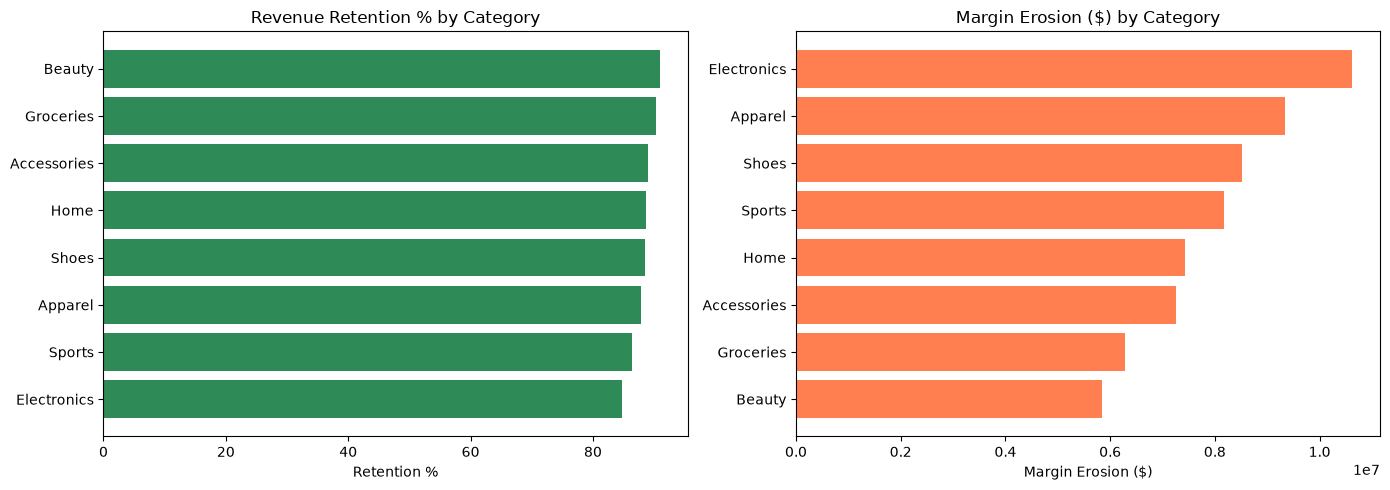

In [11]:
display(Markdown("### 📊 Step 11: Profitability Visualization"))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

profitability_sorted = profitability.sort_values('revenue_retention_pct', ascending=True)
axes[0].barh(profitability_sorted['category'], profitability_sorted['revenue_retention_pct'], color='seagreen')
axes[0].set_title('Revenue Retention % by Category')
axes[0].set_xlabel('Retention %')

profitability_sorted2 = profitability.sort_values('margin_erosion', ascending=True)
axes[1].barh(profitability_sorted2['category'], profitability_sorted2['margin_erosion'], color='coral')
axes[1].set_title('Margin Erosion ($) by Category')
axes[1].set_xlabel('Margin Erosion ($)')

plt.tight_layout()
plt.show()

In [12]:
display(Markdown("### 💾 Step 12: Save Analysis Results"))

comparison_df_v2.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\competitor_analysis_results.csv", index=False)
profitability.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\profitability_analysis.csv", index=False)

print("Competitor analysis and profitability results saved successfully!")

### 💾 Step 12: Save Analysis Results

Competitor analysis and profitability results saved successfully!
